In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.datasets import boston_housing

(x_train_set, y_train_set), (x_test, y_test) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x_train_set, y_train_set, random_state=1)

In [5]:
from sklearn.preprocessing import StandardScaler

scal = StandardScaler()
x_train = scal.fit_transform(x_train)
x_valid = scal.transform(x_valid)
x_test = scal.transform(x_test)

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, concatenate
from tensorflow.keras.optimizers import SGD

In [8]:
keras.backend.clear_session()
np.random.seed(1)
tf.random.set_seed(1)

In [9]:
imput_=Input(shape=x_train.shape[1:])
hidden1=Dense(30,activation='relu')(imput_)
hidden2=Dense(30,activation='relu')(hidden1)
concat=concatenate([imput_,hidden2])
output=Dense(1)(concat)

model1=Model(inputs=[imput_],outputs=[output])

In [10]:
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        420 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 43)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         44 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,394 (5.45 KB)

 Trainable params: 1,394 (5.45 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model1.compile(loss='mse',optimizer=SGD(learning_rate=1e-3))

In [12]:
train=model1.fit(x_train,y_train,epochs=20,validation_data=(x_valid,y_valid))

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 13))
  warnings.warn(msg)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 550.3751 - val_loss: 473.2440
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 391.2987 - val_loss: 138.4420
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 93.4971 - val_loss: 43.1704
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 32.4052 - val_loss: 29.2948
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 20.6557 - val_loss: 25.0786
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.4442 - val_loss: 22.6467
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.9598 - val_loss: 20.9320
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14.9504 - val_loss: 19.5897
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14.1271 - val_loss: 18.5012
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.4162 - val_loss: 17.5902
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12.7863 - val_loss: 16.8662
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

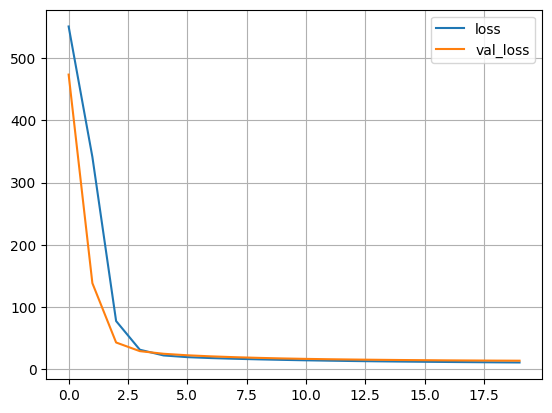

In [13]:
pd.DataFrame(train.history).plot()
plt.grid(True)
plt.show()

In [14]:
model1.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 16.8501


22.79183006286621

In [15]:
model1.predict(x_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(3, 13))
  warnings.warn(msg)


array([[ 8.417023],
       [16.670137],
       [20.458323]], dtype=float32)

In [16]:
y_test[:3]

array([ 7.2, 18.8, 19. ])

In [17]:
x_train_A, x_train_B=x_train[:,:5],x_train[:,3:]
x_valid_A, x_valid_B=x_valid[:,:5],x_valid[:,3:]
x_test_A, x_test_B=x_test[:,:5],x_test[:,3:]

In [18]:
x_train.shape, x_train_A.shape, x_train_B.shape

((303, 13), (303, 5), (303, 10))

In [19]:
input_A=Input(shape=[5],name='wide_input')
input_B=Input(shape=[10],name='deep_input')
hidden1=Dense(50,activation='relu')(input_B)
hidden2=Dense(50,activation='relu')(hidden1)
concat=concatenate([input_A,hidden2])
output=Dense(1,name='output')(concat)

model2=Model(inputs=[input_A,input_B],outputs=[output])

In [20]:
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ deep_input          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50)        │        550 │ deep_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50)        │      2,550 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 55)        │          0 │ wide_input[0][0], │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         56 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,156 (12.33 KB)

 Trainable params: 3,156 (12.33 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model2.compile(loss='mse',optimizer=SGD(learning_rate=1e-3))

In [22]:
train=model2.fit((x_train_A,x_train_B),y_train,epochs=20,validation_data=((x_valid_A,x_valid_B),y_valid))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 541.7786 - val_loss: 442.3663
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 366.1802 - val_loss: 87.2868
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 60.6836 - val_loss: 41.4794
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 32.3541 - val_loss: 34.2553
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 24.6181 - val_loss: 30.1747
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 20.6449 - val_loss: 27.2621
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 18.2275 - val_loss: 25.1222
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.6156 - val_loss: 23.5656
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.4100 - val_loss: 22.2485
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 14.4685 - val_loss: 21.1405
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.7022 - val_loss: 20.3235
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 

In [23]:
model2.evaluate((x_test_A,x_test_B),y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 18.5150 


23.58755111694336

In [25]:
model2.predict((x_test_A[:3],x_test_B[:3]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step


array([[ 8.306502],
       [16.924223],
       [20.428974]], dtype=float32)

In [26]:
y_test[:3]

array([ 7.2, 18.8, 19. ])

In [29]:
input_A=Input(shape=[5],name='wide_input')
input_B=Input(shape=[10],name='deep_input')
hidden1=Dense(50,activation='relu')(input_B)
hidden2=Dense(50,activation='relu')(hidden1)
concat=concatenate([input_A,hidden2])
output=Dense(1,name='output')(concat)
aux_output=Dense(1,name='aux_output')(hidden2)

model3=Model(inputs=[input_A,input_B],outputs=[output, aux_output])

In [30]:
model3.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ deep_input          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 50)        │        550 │ deep_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 50)        │      2,550 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 55)        │          0 │ wide_input[0][0], │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         56 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_output (Dense)  │ (None, 1)         │         51 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,207 (12.53 KB)

 Trainable params: 3,207 (12.53 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model3.compile(loss=['mse','mse'],loss_weights=[0.9,0.1],optimizer=SGD(learning_rate=1e-3))

In [32]:
train=model3.fit((x_train_A,x_train_B),[y_train,y_train],epochs=20,validation_data=((x_valid_A,x_valid_B),[y_valid,y_valid]))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - aux_output_loss: 567.8787 - loss: 545.2061 - output_loss: 544.0027 - val_aux_output_loss: 577.9404 - val_loss: 437.4291 - val_output_loss: 441.1241
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - aux_output_loss: 531.8455 - loss: 350.2935 - output_loss: 329.5128 - val_aux_output_loss: 476.7801 - val_loss: 134.2451 - val_output_loss: 105.9748
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - aux_output_loss: 411.2411 - loss: 102.8026 - output_loss: 68.9078 - val_aux_output_loss: 343.8782 - val_loss: 78.6243 - val_output_loss: 51.6716
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - aux_output_loss: 289.7501 - loss: 62.0378 - output_loss: 37.0570 - val_aux_output_loss: 245.4032 - val_loss: 56.1779 - val_output_loss: 37.7344
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - aux_output_loss: 201.1873 - loss: 43.2595 - output_loss: 25.9626 - val_aux_output_loss: 173.0193 - val_loss: 43.4951 - val_output_loss: 31.5998
Epoch 

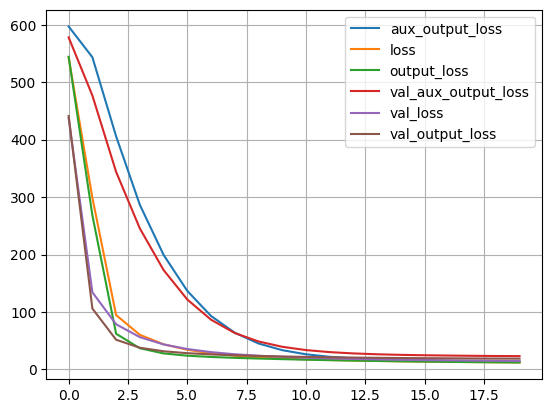

In [33]:
pd.DataFrame(train.history).plot()
plt.grid(True)
plt.show()

In [34]:
model3.evaluate((x_test_A,x_test_B),[y_test,y_test])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - aux_output_loss: 21.9520 - loss: 17.6180 - output_loss: 26.2574


[21.806367874145508, 43.47903823852539, 31.973800659179688]

In [35]:
model3.predict((x_test_A[:3],x_test_B[:3]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


[array([[ 9.452355],
        [15.482187],
        [20.706266]], dtype=float32),
 array([[10.6872225],
        [15.728211 ],
        [20.338268 ]], dtype=float32)]

In [36]:
y_test[:3]

array([ 7.2, 18.8, 19. ])